# Phase diagrams as free-energy surfaces in 3D

Every phase of a full `calc_phase_diagram(..., keep_unstable=True)` frame drawn as a surface,
in one of two spaces:

- **μ–T–φ**: the semi-grand potential $\phi(\Delta\mu, T)$ over the sampled grid. $-c\,\Delta\mu$
  dominates $\phi$, so a reference phase or the stable envelope $\min_p \phi_p$ is subtracted
  to separate the sheets. Coexisting phases share one transition curve, drawn with
  interleaved dashes in both phase colours.
- **c–T–f**: the same grid mapped through each phase's own $c(\Delta\mu, T)$ onto
  $f(c, T) = \phi + \Delta\mu\, c$, or the excess $f_\mathrm{excess}$ over the per-temperature
  endpoint tangent chord. Coexisting phases sit at different $c$, so each draws its own
  boundary curve, and the common-tangent tie lines between them form grey ruled surfaces.
  Line phases are curves $f(T)$ at their fixed $c$.

Stable parts of a surface and its unstable continuation get separate opacities (solid and
faint by default); the **floor** projects the stable diagram (μ–T or c–T) flat onto the
bottom of the box. Triple points are black; in c–T–f they are the
three-phase tie line.

The explorer renders with [k3d](https://github.com/K3D-tools/K3D-jupyter) (WebGL,
`pip install k3d`); the static gallery at the end uses matplotlib.

In [1]:
import colorsys
import io
from dataclasses import dataclass, field
from functools import cache

import ipywidgets as widgets
import k3d
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.colors import LightSource, to_hex, to_rgb
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.interpolate import RegularGridInterpolator

import landau.calculate as ldc
import landau.interpolate as ldi
import landau.phases as ldp
from landau.features import Locus
from landau.plot import get_phase_colors

STABLE_ALPHA, UNSTABLE_ALPHA, TIE_ALPHA = 1.0, 0.15, 0.5

## Geometry

Backend-independent: each phase's surface split into stable and unstable pieces, the
transition curves, tie-line strips, triple points and the floor projection.

In [2]:
ENVELOPE = "stable envelope"
# points of one coexistence line farther apart than this, in (c, normalised T),
# belong to separate branches
BRANCH_GAP = 0.05
SPACES = {"mu-T-phi": "μ–T–φ", "c-T-f": "c–T–f"}


def _saturate(color, lightness=0.42):
    h, _, _ = colorsys.rgb_to_hls(*to_rgb(color))
    return colorsys.hls_to_rgb(h, lightness, 1.0)


def _clip(poly, d):
    """Part of a polygon where the linearly interpolated ``d`` is <= 0; every column is interpolated."""
    out = []
    k = len(poly)
    for i in range(k):
        a, b, da, db = poly[i], poly[(i + 1) % k], d[i], d[(i + 1) % k]
        if da <= 0:
            out.append(a)
        if (da <= 0) != (db <= 0):
            out.append(a + da / (da - db) * (b - a))
    return np.array(out)


def reference_options(df, space):
    if space == "c-T-f":
        return ["f_excess", "f"]
    return ["none", ENVELOPE] + list(df.phase.unique())


def default_reference(space, preferred):
    return "f_excess" if space == "c-T-f" else preferred


@dataclass
class Geometry:
    """Everything a backend draws, in data coordinates (x, y, z)."""
    phases: list
    colors: dict
    labels: tuple  # axis labels
    surfaces: list = field(default_factory=list)  # (phase, stable, [polygon (k, 3)])
    lines: list = field(default_factory=list)     # (phases sharing the curve, phase, xyz (n, 3))
    line_phases: list = field(default_factory=list)  # (phase, stable, xyz (n, 3)) for zero-width surfaces
    ties: list = field(default_factory=list)      # two-phase ruled strips, [polygon (4, 3)]
    triples: list = field(default_factory=list)   # xyz (k, 3): one point (mu-T) or the tie line (c-T)
    floor: list = field(default_factory=list)     # (phase or None, [polygon (k, 2)])
    bounds: tuple = None                          # (lo (3,), hi (3,))
    shared_lines: bool = True                     # coexisting phases share one transition curve


def phase_geometry(df, space="mu-T-phi", reference=None, pairwise=False):
    """Split each phase's surface into stable and unstable pieces and collect the transitions.

    The surface of every phase is sampled on the (T, mu) grid of ``df``
    (``keep_unstable=True``). In ``"mu-T-phi"`` it is drawn at (mu, T, phi - reference),
    in ``"c-T-f"`` at (c, T, f) or (c, T, f_excess), using the same grid connectivity.
    Grid cells are cut along the linearly interpolated crossing with the lowest
    competing phase; with ``pairwise`` also along the crossing with every other
    phase, which the per-polygon depth sort of matplotlib needs.
    """
    grid = df[(df.locus == Locus.INTERIOR) & np.isfinite(df.mu)]
    Ts = np.sort(grid["T"].unique())
    mus = np.sort(grid["mu"].unique())
    phases = list(df.phase.unique())
    colors = get_phase_colors(phases)
    ctf = space == "c-T-f"
    zcol = (reference or "f_excess") if ctf else "phi"

    def pivot(col, p):
        return (grid[grid.phase == p].pivot_table(index="T", columns="mu", values=col, aggfunc="first")
                .reindex(index=Ts, columns=mus).to_numpy(dtype=float))

    phi = {p: pivot("phi", p) for p in phases}
    stack = np.stack([phi[p] for p in phases])
    if ctf or reference in (None, "none"):
        ref = np.zeros_like(stack[0])
    elif reference == ENVELOPE:
        ref = np.nanmin(stack, axis=0)
    else:
        ref = phi[reference]
    ref_at = RegularGridInterpolator((Ts, mus), ref, bounds_error=False, fill_value=None)

    if ctf:
        labels = ("c", r"T\ [\mathrm{K}]", r"f\ [\mathrm{eV}]" if zcol == "f" else r"f_\mathrm{excess}\ [\mathrm{eV}]")
    else:
        name = str(reference).replace("$", "")
        zlabel = {None: r"\varphi", "none": r"\varphi", ENVELOPE: r"\varphi - \min_p \varphi_p"}.get(
            reference, rf"\varphi - \varphi_\mathrm{{{name}}}")
        labels = (r"\Delta\mu\ [\mathrm{eV}]", r"T\ [\mathrm{K}]", zlabel + r"\ [\mathrm{eV}]")
    geo = Geometry(phases, colors, labels, shared_lines=not ctf)

    M, T = np.meshgrid(mus, Ts)
    corners = [(slice(None, -1), slice(None, -1)), (slice(None, -1), slice(1, None)),
               (slice(1, None), slice(1, None)), (slice(1, None), slice(None, -1))]
    for i, p in enumerate(phases):
        cp = pivot("c", p)
        if ctf and np.nanmax(cp) - np.nanmin(cp) < 1e-9:
            # zero-width surface: a line phase is a curve f(T) at fixed c, stable at the
            # temperatures where it is stable at some mu; one curve per contiguous run
            st = (pivot("stable", p) > 0.5).any(axis=1)
            z = np.nanmin(np.where(np.isfinite(pivot(zcol, p)), pivot(zcol, p), np.inf), axis=1)
            ok = np.isfinite(z)
            for run in np.split(np.arange(len(Ts)), np.flatnonzero(np.diff(st)) + 1):
                run = run[ok[run]]
                if len(run):
                    # extend a run by one sample into the next so the curves join
                    run = np.r_[run, run[-1] + 1] if run[-1] + 1 < len(Ts) and ok[run[-1] + 1] else run
                    geo.line_phases.append((p, bool(st[run[0]]), np.c_[np.full(len(run), np.nanmean(cp)), Ts[run], z[run]]))
            continue
        if ctf:
            X, Z = cp, pivot(zcol, p)
        else:
            X, Z = M, phi[p] - ref
        others = [q for q in phases if q != p]
        dmin = phi[p] - np.nanmin(np.stack([phi[q] for q in others]), axis=0) if others else -np.ones_like(phi[p])
        ds = [dmin] + ([phi[p] - phi[q] for q in others] if pairwise else [])
        # a missing competitor never undercuts
        ds = [np.where(np.isfinite(d), d, np.where(np.isfinite(phi[p]), -1.0, np.nan)) for d in ds]
        cols = [X, T, Z, *ds]
        Q = np.stack([np.stack([a[c] for a in cols], -1) for c in corners], -2)  # (nT-1, nmu-1, 4, ncol)
        Q = Q[np.isfinite(Q).all((-1, -2))]
        D = Q[..., 3:]
        pure = ((D <= 0).all(1) | (D > 0).all(1)).all(-1)
        stable_pure = (D[pure, :, 0] <= 0).all(-1)
        pieces = {True: list(Q[pure][stable_pure][..., :3]), False: list(Q[pure][~stable_pure][..., :3])}
        for q in Q[~pure]:
            parts = [q]
            for j in range(3, q.shape[1]):
                split = []
                for part in parts:
                    d = part[:, j]
                    if (d <= 0).all() or (d > 0).all():
                        split.append(part)
                    else:
                        split += [x for x in (_clip(part, d), _clip(part, -d)) if len(x) >= 3]
                parts = split
            for part in parts:
                pieces[bool(part[:, 3].mean() <= 0)].append(part[:, :3])
        for stable in (True, False):
            if pieces[stable]:
                geo.surfaces.append((p, stable, pieces[stable]))
        if pieces[True]:
            geo.floor.append((p, [v[:, :2] for v in pieces[True]]))

    # Transitions. boundary_id is numbered per refiner, so a line is keyed by
    # (refiner, boundary_id). One phase pair can coexist on disjoint branches: either
    # side of a congruent point, told apart by the side of the pair's mean c the
    # alphabetically first phase sits on, and either side of an intermediate phase,
    # told apart by connectivity in (mean c, T): mu is no measure of distance, it
    # diverges towards the pure components. A phase coexisting with itself
    # (miscibility gap) has two curves, one per side of the pair's mean c.
    rows = df[(df.locus != Locus.INTERIOR) & df.stable & np.isfinite(df.mu)
              & df.mu.between(mus.min(), mus.max()) & df["T"].between(Ts.min(), Ts.max())].copy()
    if ctf and zcol == "f_excess":
        # f_excess is referenced per temperature group, and a refined row's group holds
        # only its coexisting phases, so its f_excess is not comparable to the grid's.
        # Re-reference against the grid's chord f - f_excess = a(T) + b(T) c instead.
        chord = grid[np.isfinite(grid.f_excess)].assign(r=lambda x: x.f - x.f_excess).groupby("T")[["c", "r"]]
        ab = chord.apply(lambda x: pd.Series(np.polyfit(x.c, x.r, 1) if x.c.nunique() > 1 else [0.0, x.r.mean()],
                                             index=["b", "a"]), include_groups=False)
        a_T = np.interp(rows["T"], ab.index, ab.a)
        b_T = np.interp(rows["T"], ab.index, ab.b)
        rows["z"] = rows.f - a_T - b_T * rows.c
    elif ctf:
        rows["z"] = rows[zcol]
    else:
        rows["z"] = rows.phi - ref_at(np.c_[rows["T"], rows["mu"]])
    rows["x"] = rows.c if ctf else rows.mu
    tp = rows[rows.locus == Locus.TRIPLE]
    for _, g in tp.groupby(["T", "mu"]):
        g = g.sort_values("x").drop_duplicates("phase")
        geo.triples.append(g[["x", "T", "z"]].to_numpy() if ctf else g[["x", "T", "z"]].to_numpy()[:1])
    rows = rows[rows.locus != Locus.TRIPLE]
    key = ["refined", "boundary_id", "T", "mu"]
    rows["side"] = np.sign(rows.c - rows.groupby(key).c.transform("mean"))
    rows = rows.sort_values(["phase", "side"])
    rows["branch"] = rows.groupby(key).side.transform("first")
    # a point where the pair shares one c (congruent) closes both branches
    shared = rows[rows.branch == 0]
    rows = pd.concat([rows[rows.branch != 0], shared.assign(branch=1.0), shared.assign(branch=-1.0)],
                     ignore_index=True)
    rows["c_pair"] = rows.groupby(key).c.transform("mean")
    parts = []
    for _, line in rows.groupby(["refined", "boundary_id", "branch"]):
        pts = line[["mu", "T", "c_pair"]].drop_duplicates(["mu", "T"])
        if len(pts) > 1:
            scaled = np.c_[pts.c_pair, (pts["T"] - Ts.min()) / (Ts.max() - Ts.min())]
            label = fcluster(linkage(scaled, "single"), t=BRANCH_GAP, criterion="distance")
        else:
            label = np.zeros(len(pts), dtype=int)
        label = line[["mu", "T"]].merge(pts[["mu", "T"]].assign(part=label), on=["mu", "T"], how="left").part
        parts.append(pd.Series(label.to_numpy(), index=line.index))
    rows["part"] = pd.concat(parts) if parts else 0
    for _, line in rows.groupby(["refined", "boundary_id", "branch", "part"]):
        members = tuple(sorted(line.phase.unique()))
        curves = []
        for (p, side), g in line.groupby(["phase", "side"]):
            g = g.drop_duplicates(["T", "mu"]).sort_values(["T", "mu"])
            curves.append(g)
            geo.lines.append((members, p, g[["x", "T", "z"]].to_numpy()))
        if ctf and len(curves) == 2:
            a, b = (c.set_index(["T", "mu"])[["x", "z"]] for c in curves)
            both = a.join(b, lsuffix="1", rsuffix="2", how="inner").sort_index()
            Tv = both.index.get_level_values("T").to_numpy()
            P1 = np.c_[both.x1, Tv, both.z1]
            P2 = np.c_[both.x2, Tv, both.z2]
            geo.ties += [np.array([P1[k], P1[k + 1], P2[k + 1], P2[k]]) for k in range(len(Tv) - 1)]

    allv = np.concatenate([np.concatenate(v) for _, _, v in geo.surfaces]
                          + [xyz for _, _, xyz in geo.line_phases] + [np.zeros((0, 3))])
    lo, hi = np.nanmin(allv, axis=0), np.nanmax(allv, axis=0)
    if ctf:
        lo[0], hi[0] = 0.0, 1.0
    else:
        lo[0], hi[0] = mus.min(), mus.max()
    lo[1], hi[1] = Ts.min(), Ts.max()
    if hi[2] == lo[2]:
        lo[2], hi[2] = lo[2] - 1e-3, hi[2] + 1e-3
    geo.bounds = (lo, hi)
    return geo

## k3d backend

In [3]:
BOX = np.array([1.0, 1.0, 0.7])  # drawn extent of the (x, y, z) data box
FLOOR = -0.08                     # floor height below the box, in drawn units
TWO_PHASE = "#d9d9d9"
# eye, target, up; roughly the matplotlib view_init(elev=22, azim=-60)
CAMERA = [1.3, -0.8, 0.95, 0.5, 0.5, 0.25, 0, 0, 1]


def _hex(color):
    r, g, b = (int(round(255 * v)) for v in to_rgb(color))
    return (r << 16) + (g << 8) + b


def _fan(polys):
    """Triangulate polygons (convex, from clipping a grid cell) into a shared-vertex mesh."""
    verts, tris, n = [], [], 0
    for v in polys:
        k = len(v)
        verts.append(v)
        tris.append(np.c_[np.full(k - 2, n), np.arange(n + 1, n + k - 1), np.arange(n + 2, n + k)])
        n += k
    verts, tris = np.concatenate(verts), np.concatenate(tris)
    # merge coincident corners so k3d interpolates normals across cells
    _, inv = np.unique(np.round(verts, 7), axis=0, return_inverse=True)
    uniq = np.zeros((inv.max() + 1, verts.shape[1]))
    uniq[inv.ravel()] = verts
    return uniq.astype(np.float32), inv.ravel()[tris].astype(np.uint32)


def _dashes(xyz, n, k, dash):
    """Segments of every n-th dash (offset k) along the polyline, dash length in drawn units."""
    seg = np.linalg.norm(np.diff(xyz, axis=0), axis=1)
    s = np.r_[0, np.cumsum(seg)]
    if s[-1] == 0:
        return None
    t = np.arange(0, s[-1] + dash, dash)
    t[-1] = min(t[-1], s[-1])
    pts = np.stack([np.interp(t, s, xyz[:, i]) for i in range(3)], -1)
    idx = np.arange(k, len(pts) - 1, n)
    if not len(idx):
        return None
    return pts.astype(np.float32), np.c_[idx, idx + 1].astype(np.uint32)


def draw_k3d(geo, plot=None, floor=True, stable_alpha=STABLE_ALPHA, unstable_alpha=UNSTABLE_ALPHA,
             show_unstable=True, width=0.006, dash=0.02):
    """Add the geometry to a k3d plot (a new one unless given) and return (plot, objects)."""
    import k3d

    lo, hi = geo.bounds
    span = np.where(hi > lo, hi - lo, 1.0)

    def norm(v):
        v = np.asarray(v, dtype=float)
        return (v - lo[: v.shape[-1]]) / span[: v.shape[-1]] * BOX[: v.shape[-1]]

    def at_floor(v2):
        v2 = norm(v2)
        return np.c_[v2, np.full(len(v2), FLOOR)]

    objs = []
    for p, stable, polys in geo.surfaces:
        if not stable and not show_unstable:
            continue
        v, t = _fan([norm(x) for x in polys])
        objs.append(k3d.mesh(v, t, color=_hex(geo.colors[p]), opacity=stable_alpha if stable else unstable_alpha,
                             flat_shading=False, side="double", name=f"{p} {'stable' if stable else 'unstable'}"))
    if geo.ties:
        v, t = _fan([norm(x) for x in geo.ties])
        objs.append(k3d.mesh(v, t, color=_hex(TWO_PHASE), opacity=min(stable_alpha, TIE_ALPHA),
                             flat_shading=False, side="double", name="two-phase"))
    for p, stable, xyz in geo.line_phases:
        if not stable and not show_unstable:
            continue
        objs.append(k3d.line(norm(xyz).astype(np.float32), color=_hex(geo.colors[p] if not stable else _saturate(geo.colors[p])),
                             width=2 * width if stable else width, shader="mesh", opacity=1.0 if stable else unstable_alpha,
                             name=f"{p} line phase"))
    if floor:
        for p, polys in geo.floor:
            v, t = _fan([at_floor(x) for x in polys])
            objs.append(k3d.mesh(v, t, color=_hex(geo.colors[p]), flat_shading=True, side="double", name=f"{p} floor"))
        if geo.ties:
            v, t = _fan([at_floor(x[:, :2]) for x in geo.ties])
            objs.append(k3d.mesh(v, t, color=_hex(TWO_PHASE), flat_shading=True, side="double", name="two-phase floor"))
        for p, stable, xyz in geo.line_phases:
            if stable:
                objs.append(k3d.line(at_floor(xyz[:, :2]).astype(np.float32), color=_hex(_saturate(geo.colors[p])),
                                     width=2 * width, shader="mesh"))
    for members, p, xyz in geo.lines:
        heights = [norm(xyz)] + ([at_floor(xyz[:, :2])] if floor else [])
        for v in heights:
            if len(v) < 2:
                continue
            color = _hex(_saturate(geo.colors[p]))
            if len(members) > 1 and geo.shared_lines:
                d = _dashes(v, len(members), members.index(p), dash)
                if d is not None:
                    objs.append(k3d.lines(*d, indices_type="segment", color=color, width=width, shader="mesh"))
            else:
                objs.append(k3d.line(v.astype(np.float32), color=color, width=width, shader="mesh"))
    for xyz in geo.triples:
        for v in [norm(xyz)] + ([at_floor(xyz[:, :2])] if floor else []):
            objs.append(k3d.points(v.astype(np.float32), color=0x000000, point_size=0.025, shader="mesh"))
            if len(v) > 1:
                objs.append(k3d.line(v.astype(np.float32), color=0x000000, width=width, shader="mesh"))

    # box, ticks and axis labels in drawn units; k3d's own grid would label the normalised values
    z0 = FLOOR if floor else 0.0
    X, Y, Z = BOX
    edges = [[(0, 0, z0), (X, 0, z0)], [(0, 0, z0), (0, Y, z0)], [(X, 0, z0), (X, Y, z0)], [(0, Y, z0), (X, Y, z0)],
             [(0, Y, z0), (0, Y, Z)], [(X, Y, z0), (X, Y, Z)], [(0, Y, Z), (X, Y, Z)]]
    ev = np.array(edges, dtype=np.float32).reshape(-1, 3)
    objs.append(k3d.lines(ev, np.arange(len(ev), dtype=np.uint32).reshape(-1, 2), indices_type="segment",
                          color=0x888888, width=0.003, shader="mesh"))
    for axis in range(3):
        ticks = MaxNLocator(5).tick_values(lo[axis], hi[axis])
        ticks = ticks[(ticks >= lo[axis] - 1e-12) & (ticks <= hi[axis] + 1e-12)]
        for tv in ticks:
            u = (tv - lo[axis]) / span[axis] * BOX[axis]
            pos = [(u, -0.05, z0), (X + 0.05, u, z0), (X + 0.03, Y, u)][axis]
            objs.append(k3d.text(f"{tv:.4g}", position=pos, color=0x444444, size=0.6, label_box=False,
                                 reference_point="cc"))
        pos = [(X / 2, -0.14, z0), (X + 0.16, Y / 2, z0), (X + 0.12, Y, Z / 2 + 0.08)][axis]
        objs.append(k3d.text(geo.labels[axis], position=pos, color=0x000000, size=0.8, label_box=False,
                             reference_point="cc"))
    legend = "".join(f'<div><span style="display:inline-block;width:12px;height:12px;background:{to_hex(geo.colors[p])};'
                     f'margin-right:6px"></span>{p}</div>' for p in geo.phases)
    objs.append(k3d.text2d(legend, position=(0.01, 0.01), is_html=True, label_box=False, size=0.9, color=0x000000))

    if plot is None:
        plot = k3d.plot(grid_visible=False, axes_helper=0, depth_peels=8, lighting=1.2, height=600,
                        menu_visibility=False, camera_up_axis="z", camera_auto_fit=False)
        plot.camera = CAMERA
    for o in objs:
        plot += o
    # k3d culls text labels against the camera frustum of the last camera change;
    # re-setting the camera refreshes it (otherwise labels stay hidden until the first drag)
    plot.camera = list(plot.camera) if len(plot.camera) else CAMERA
    return plot, objs

## matplotlib backend

In [4]:
def _newell(v):
    """Polygon normal, robust for the non-planar quads of a curved surface."""
    r = np.roll(v, -1, axis=0)
    return np.array([
        np.sum((v[:, 1] - r[:, 1]) * (v[:, 2] + r[:, 2])),
        np.sum((v[:, 2] - r[:, 2]) * (v[:, 0] + r[:, 0])),
        np.sum((v[:, 0] - r[:, 0]) * (v[:, 1] + r[:, 1])),
    ])


def _mathtext(label):
    return f"${label}$"


def draw_mpl(geo, ax, floor=True, stable_alpha=STABLE_ALPHA, unstable_alpha=UNSTABLE_ALPHA, show_unstable=True, dash=4.0):
    """Draw the geometry onto a matplotlib 3d axes (static renders).

    Build ``geo`` with ``pairwise=True``: mplot3d sorts whole polygons by depth, so
    translucent sheets only blend in a consistent order when every piece lies
    wholly above or below every other surface.
    """
    lo, hi = geo.bounds
    span = np.where(hi > lo, hi - lo, 1.0)
    z0 = lo[2] - 0.1 * span[2] if floor else lo[2]

    verts, fcs = [], []
    for p, stable, polys in geo.surfaces:
        if stable or show_unstable:
            rgb = np.array(to_rgb(geo.colors[p]))
            verts += polys
            fcs += [np.r_[rgb, stable_alpha if stable else unstable_alpha]] * len(polys)
    for v in geo.ties:
        verts.append(v)
        fcs.append(np.r_[to_rgb(TWO_PHASE), min(stable_alpha, TIE_ALPHA)])
    fcs = np.array(fcs)
    # Lambert shading in axis-normalised coordinates so the three axes weigh equally
    n = np.array([_newell(v / span) for v in verts])
    norm = np.linalg.norm(n, axis=1, keepdims=True)
    n = np.where(norm > 0, n / np.where(norm > 0, norm, 1), [0.0, 0.0, 1.0])  # collapsed cells face up
    n *= np.sign(n[:, 2:3] + 1e-300)
    shade = LightSource(azdeg=225, altdeg=45).shade_normals(n, fraction=1.0)
    fcs[:, :3] *= (0.55 + 0.45 * shade)[:, None]

    def flat(v2):
        return np.c_[v2, np.full(len(v2), z0)]

    if floor:
        fpolys, fcols = [], []
        for p, polys in geo.floor:
            fpolys += [flat(v) for v in polys]
            fcols += [to_rgb(geo.colors[p])] * len(polys)
        fpolys += [flat(v[:, :2]) for v in geo.ties]
        fcols += [to_rgb(TWO_PHASE)] * len(geo.ties)
        if fpolys:
            ax.add_collection3d(Poly3DCollection(fpolys, facecolors=fcols, edgecolors=fcols, linewidths=0.3, zorder=0))
    ax.add_collection3d(Poly3DCollection(verts, facecolors=fcs, edgecolors="none", zorder=1))

    for p, stable, xyz in geo.line_phases:
        if stable or show_unstable:
            c = _saturate(geo.colors[p]) if stable else geo.colors[p]
            ax.plot(*xyz.T, color=c, lw=3 if stable else 1.2, alpha=1 if stable else unstable_alpha, zorder=10)
            if floor and stable:
                ax.plot(xyz[:, 0], xyz[:, 1], np.full(len(xyz), z0), color=c, lw=3, zorder=2)
    for members, p, xyz in geo.lines:
        k = members.index(p)
        ls = "-" if len(members) == 1 or not geo.shared_lines else (k * dash, (dash, (len(members) - 1) * dash))
        c = _saturate(geo.colors[p])
        ax.plot(*xyz.T, color=c, lw=2.2, ls=ls, zorder=10)
        if floor:
            ax.plot(xyz[:, 0], xyz[:, 1], np.full(len(xyz), z0), color=c, lw=2.2, ls=ls, zorder=2)
    for xyz in geo.triples:
        for z in [xyz[:, 2]] + ([np.full(len(xyz), z0)] if floor else []):
            ax.plot(xyz[:, 0], xyz[:, 1], z, color="k", lw=1.2, marker="o", ms=4, zorder=11)

    ax.set(xlim=(lo[0], hi[0]), ylim=(lo[1], hi[1]), zlim=(z0, hi[2]))
    ax.set_xlabel(_mathtext(geo.labels[0]))
    ax.set_ylabel(_mathtext(geo.labels[1]))
    ax.set_zlabel(_mathtext(geo.labels[2]))
    handles = [plt.Rectangle((0, 0), 1, 1, color=geo.colors[p]) for p in geo.phases]
    ax.legend(handles, geo.phases, loc="upper left")
    ax.view_init(elev=22, azim=-60)
    return ax

## Systems

The phases of every `tests/integration/testplots.py` system, each sampled on a 2d $(T, \Delta\mu)$
grid. The 2d testplots keep their own grids; the 1d scans (`1d_*`) and the excess-free-energy
systems are widened to a temperature range around their original cut. Frames are cached, so
switching back to a system is instant.

In [5]:
kB = ldp.kB
LP, TDLP, IS = ldp.LinePhase, ldp.TemperatureDependentLinePhase, ldp.IdealSolution


def basics():
    """2d_basics / 2d_basics_mu: hcp / fcc / liquid ideal solutions (Basics.ipynb)."""
    fcc = IS("fcc", LP("fccA", 0, -3.00, 1.0 * kB), LP("fccB", 1, -2.00, 1.1 * kB))
    hcp = IS("hcp", LP("hcpA", 0, -2.975, 1.8 * kB), LP("hcpB", 1, -1.95, 1.1 * kB))
    lqd = IS("liquid", LP("liquidA", 0, -2.75, 5.0 * kB), LP("liquidB", 1, -1.75, 4.4 * kB))
    return [hcp, fcc, lqd], np.linspace(200, 1000, 60), np.linspace(0.5, 1.5, 60)


def toy():
    """2d_toy / 2d_toy_mu: regular-solution liquid + intermediate solid (Toy.ipynb)."""
    Tk = [1, 750, 1000]
    l0 = TDLP("l0", fixed_concentration=0, temperatures=Tk, free_energies=[2.00, 1.80, 1.00], interpolator=ldi.PolyFit(3))
    l1 = TDLP("l1", fixed_concentration=1, temperatures=Tk, free_energies=[3.00, 2.80, 2.00], interpolator=ldi.PolyFit(3))
    l2 = TDLP("l2", fixed_concentration=0.5, temperatures=Tk, free_energies=[2.45, 2.00, 1.42], interpolator=ldi.PolyFit(3))
    s0 = TDLP("s0", fixed_concentration=0, temperatures=Tk, free_energies=[1.9, 1.6, 1.2], interpolator=ldi.SGTE(2))
    s1 = TDLP("s1", fixed_concentration=1, temperatures=Tk, free_energies=[2.9, 2.6, 2.2], interpolator=ldi.SGTE(2))
    s3 = TDLP("s3", fixed_concentration=0.4, temperatures=Tk,
              free_energies=np.array([2.4, 1.85, 1.45]) - 0.05, interpolator=ldi.SGTE(3))
    c = np.linspace(0, 1, 75)[1:-1]
    mu = 1 + kB * 4000 * np.log(c / (1 - c))
    return ([ldp.FastInterpolatingPhase("liquid", [l0, l2, l1]), IS("solid", s0, s1), s3],
            np.linspace(500, 1000, 40), mu)


def azeotrope():
    """2d_azeotrope / 2d_azeotrope_mu: water-ethanol vapour-liquid lens (TransitionTemperatures.ipynb)."""
    T_w, T_e = 373.15, 351.4
    S_w, S_e = 40.65e3 / T_w / 8.314, 38.6e3 / T_e / 8.314
    c_az, T_az = 0.894, 351.3

    def g(c):
        return (1 - c) * S_w * kB * (T_w - T_az) + c * S_e * kB * (T_e - T_az)

    c = c_az
    M = np.array([[c * (1 - c), c * (1 - c) * (2 * c - 1)],
                  [1 - 2 * c, (1 - 2 * c) * (2 * c - 1) + 2 * c * (1 - c)]])
    L0, L1 = np.linalg.solve(M, [g(c), g(1) - g(0)])
    controls = [LP(f"l{i}", fixed_concentration=x, line_energy=x * (1 - x) * (L0 + L1 * (2 * x - 1)), line_entropy=0.0)
                for i, x in enumerate([0, 0.25, 0.5, 0.75, 1])]
    liquid = ldp.FastInterpolatingPhase("liquid", controls, add_entropy=True, interpolator=ldi.PolyFit(4))
    vapour = IS("vapour", LP("vw", 0, S_w * kB * T_w, S_w * kB), LP("ve", 1, S_e * kB * T_e, S_e * kB))
    return [liquid, vapour], np.linspace(340, 385, 60), 60


def intermetallic_sigma():
    """excess_free_energy: solid / liquid / AB2 / sigma (ExcessFreeEnergy.ipynb), 500-1600 K."""
    solid = IS("solid", LP("A", 0, -2.0, 1.0 * kB), LP("B", 1, -3.0, 1.5 * kB))
    liquid = IS("liquid", LP("A(l)", 0, -1.9, 2.5 * kB), LP("B(l)", 1, -2.9, 2.2 * kB))
    inter = LP("AB$_2$", 2 / 3, -2.8, 1.3 * kB)
    sigma = ldp.FastInterpolatingPhase("sigma", [
        LP(f"sig@{x:.2f}", fixed_concentration=x, line_energy=e)
        for x, e in [(0.30, -2.30), (0.40, -2.50), (0.50, -2.60), (0.60, -2.55), (0.70, -2.40)]
    ])
    return [solid, liquid, inter, sigma], np.linspace(500, 1600, 50), 60


def line_phases():
    """excess_free_energy_line_phases: A / B / AB line phases, 500-1500 K."""
    return ([LP("A", 0, -2.0, 1.0 * kB), LP("B", 1, -3.0, 1.5 * kB), LP("AB", 0.5, -2.8, 1.3 * kB)],
            np.linspace(500, 1500, 40), np.linspace(-2.5, 0.5, 60))


def bcc_fcc_liquid_T():
    """1d_T_*: bcc / fcc / liquid pure-element TemperatureDependentLinePhases (phi flat in mu)."""
    T_s = np.array([100.0, 400.0, 700.0, 1000.0])
    return ([TDLP("bcc", fixed_concentration=0, temperatures=T_s, free_energies=-3.00 - 2e-4 * T_s - 1e-7 * T_s**2),
             TDLP("fcc", fixed_concentration=0, temperatures=T_s, free_energies=-2.97 - 2.857e-4 * T_s - 2e-7 * T_s**2),
             TDLP("liquid", fixed_concentration=0, temperatures=T_s, free_energies=-2.75 - 3.5e-4 * T_s - 5e-7 * T_s**2)],
            np.linspace(100, 1000, 50), np.linspace(-0.5, 0.5, 20))


def hcp_fcc_liquid_mu():
    """1d_mu_three_stable / 1d_mu_reference_phase: hcp / fcc / liquid (1000 K cut), 600-1400 K."""
    fcc = IS("fcc", LP("fccA", 0, -3.02, 1.0 * kB), LP("fccB", 1, -2.02, 1.1 * kB))
    hcp = IS("hcp", LP("hcpA", 0, -2.975, 1.8 * kB), LP("hcpB", 1, -1.95, 1.1 * kB))
    lqd = IS("liquid", LP("liquidA", 0, -2.724, 1.5 * kB), LP("liquidB", 1, -2.050, 1.2 * kB))
    return [hcp, fcc, lqd], np.linspace(600, 1400, 50), 60


def intermetallic_mu():
    """1d_mu_intermetallic: A/B solid solution + AB2 line phase (600 K cut), 300-1200 K."""
    solid = IS("solid", LP("A", 0, -2.0, 1.0 * kB), LP("B", 1, -3.0, 1.5 * kB))
    return [solid, LP("AB$_2$", 2 / 3, -2.8, 1.3 * kB)], np.linspace(300, 1200, 50), 60


SYSTEMS = {
    "basics (2d_basics)": (basics, "liquid"),
    "toy (2d_toy)": (toy, "liquid"),
    "azeotrope (2d_azeotrope)": (azeotrope, "liquid"),
    "intermetallic + sigma (excess_free_energy)": (intermetallic_sigma, ENVELOPE),
    "line phases (excess_free_energy_line_phases)": (line_phases, ENVELOPE),
    "bcc/fcc/liquid (1d_T_*)": (bcc_fcc_liquid_T, "liquid"),
    "hcp/fcc/liquid (1d_mu_*)": (hcp_fcc_liquid_mu, "liquid"),
    "solid + AB2 (1d_mu_intermetallic)": (intermetallic_mu, "solid"),
}


@cache
def frame(name):
    phases, Ts, mu = SYSTEMS[name][0]()
    return ldc.calc_phase_diagram(phases, Ts, mu, refine=True, keep_unstable=True)

## Explorer

Drag to rotate, scroll to zoom. Switching space or system keeps the camera.

In [6]:
system_w = widgets.Dropdown(options=list(SYSTEMS), description="system", layout={"width": "480px"})
space_w = widgets.ToggleButtons(options=[(v, k) for k, v in SPACES.items()], description="space")
reference_w = widgets.Dropdown(description="reference", layout={"width": "480px"})
floor_w = widgets.Checkbox(value=True, description="floor projection")
unstable_w = widgets.Checkbox(value=True, description="show unstable")
stable_alpha_w = widgets.FloatSlider(value=STABLE_ALPHA, min=0.05, max=1.0, step=0.05, description="stable α")
unstable_alpha_w = widgets.FloatSlider(value=UNSTABLE_ALPHA, min=0.02, max=1.0, step=0.02, description="unstable α")

view = k3d.plot(grid_visible=False, axes_helper=0, depth_peels=8, lighting=1.2, height=600,
                menu_visibility=False, camera_up_axis="z", camera_auto_fit=False)
view.camera = CAMERA
_shown = []
_updating = False


def redraw(*_):
    global _shown, view
    if _updating or reference_w.value is None:
        return
    geo = phase_geometry(frame(system_w.value), space_w.value, reference_w.value)
    for o in _shown:
        view -= o
    _, _shown = draw_k3d(geo, view, floor=floor_w.value, stable_alpha=stable_alpha_w.value,
                         unstable_alpha=unstable_alpha_w.value, show_unstable=unstable_w.value)


def on_system(*_):
    global _updating
    df = frame(system_w.value)
    _updating = True
    reference_w.options = reference_options(df, space_w.value)
    reference_w.value = default_reference(space_w.value, SYSTEMS[system_w.value][1])
    _updating = False
    redraw()


system_w.observe(on_system, "value")
space_w.observe(on_system, "value")
for w in (reference_w, floor_w, unstable_w, stable_alpha_w, unstable_alpha_w):
    w.observe(redraw, "value")

display(widgets.VBox([system_w, space_w, reference_w, widgets.HBox([floor_w, unstable_w]),
                      widgets.HBox([stable_alpha_w, unstable_alpha_w]), view]))
on_system()

## Static gallery

Every system at its default reference and opacities, with the floor, μ–T–φ on the left and c–T–f on the
right, for viewers without a live kernel.

/home/user/landau/landau/interpolate/basic.py:280: OptimizeWarning: Covariance of the parameters could not be estimated
  parameters, *_ = so.curve_fit(G_calphad, x, y, p0=[0] * self.nparam)


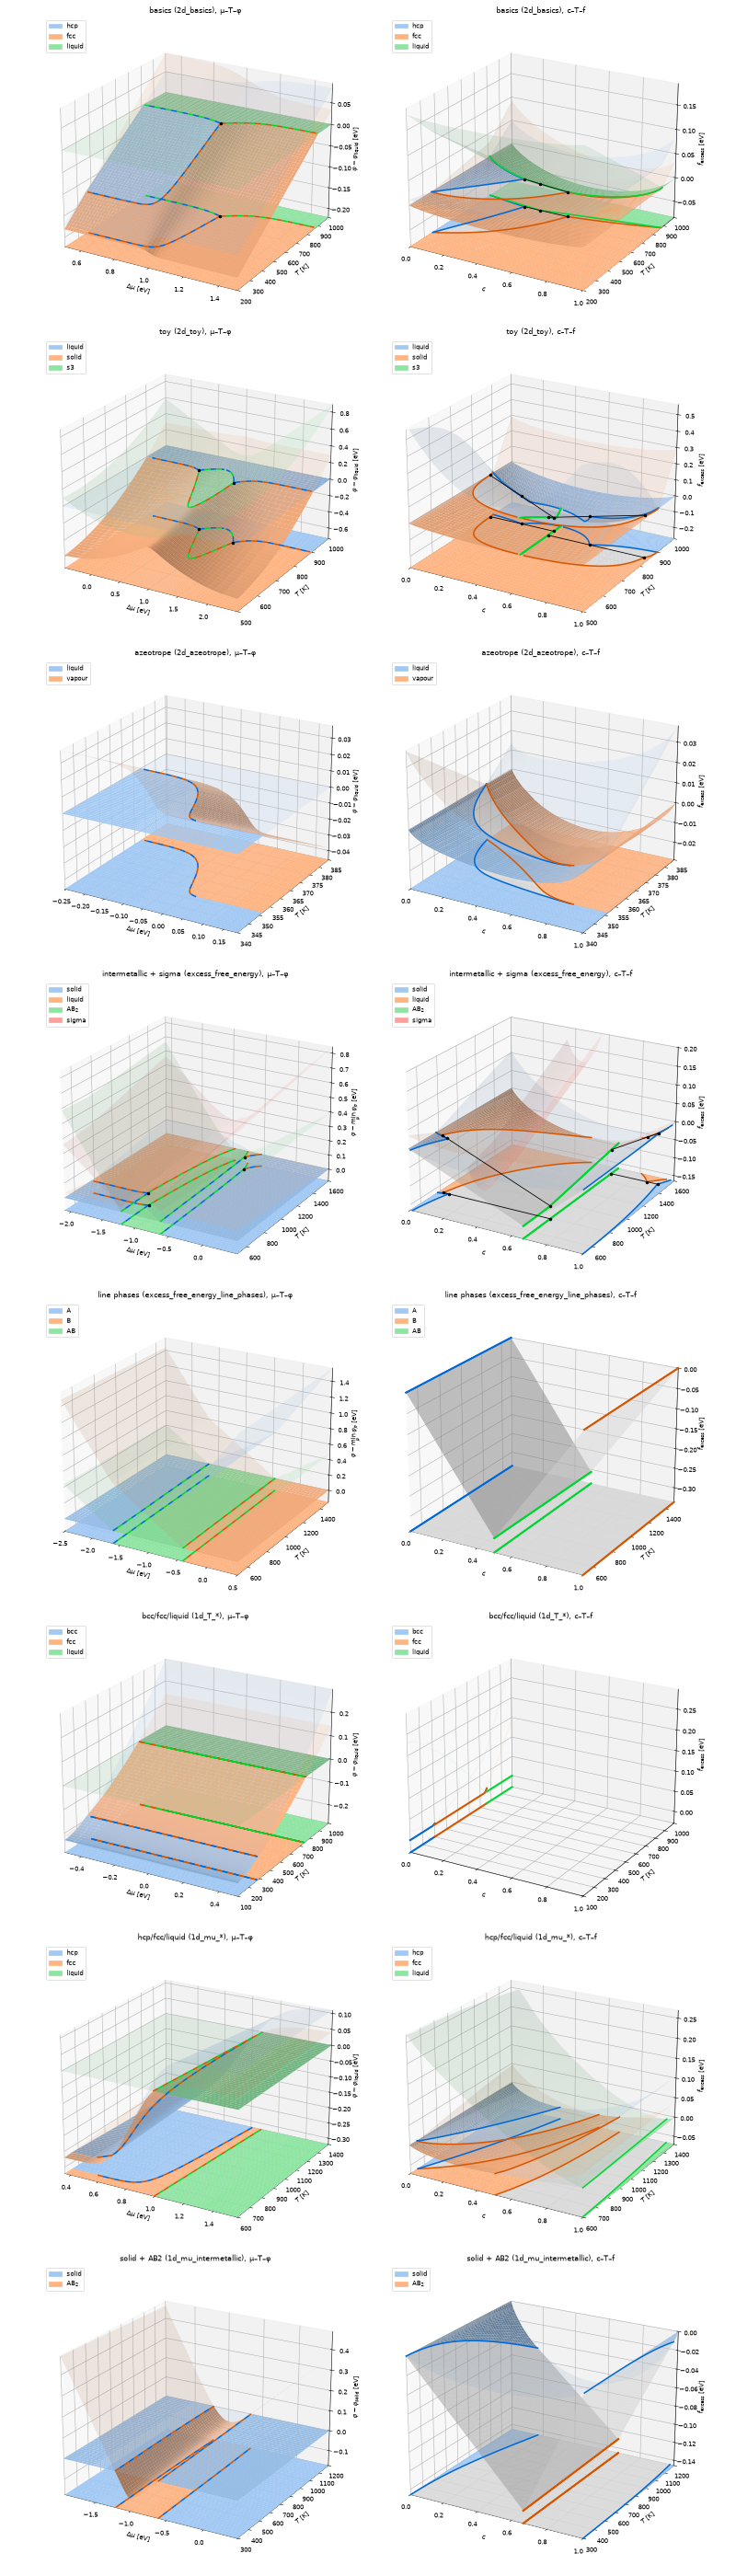

In [7]:
with plt.ioff():
    gallery = plt.figure(figsize=(16, 7 * len(SYSTEMS)))
for i, (name, (_, ref)) in enumerate(SYSTEMS.items()):
    for j, space in enumerate(SPACES):
        ax = gallery.add_subplot(len(SYSTEMS), 2, 2 * i + j + 1, projection="3d", computed_zorder=False)
        draw_mpl(phase_geometry(frame(name), space, default_reference(space, ref), pairwise=True), ax)
        ax.set_title(f"{name}, {SPACES[space]}")
gallery.tight_layout()
buf = io.BytesIO()
gallery.savefig(buf, format="png", dpi=50)
plt.close(gallery)
display(Image(buf.getvalue()))

## Notes for a library implementation

This notebook is a demo; its geometry code is written for it and deliberately not in `landau`.
Before any of it moves into the package:

- **Transition branches.** `get_transitions` already splits the boundary rows of each phase
  pair into disconnected segments (`border_segment`, via `cluster_T_c_mu`). The demo's own
  split (side of the pair's mean $c$, then single-linkage in (mean $c$, $T$)) duplicates it and
  should be replaced by `border_segment`.
- **Floor.** The projected stable diagram is the per-phase stable-region polygon set that
  `get_polygons` already builds in c–T and μ–T; drawing its output flat keeps the floor
  identical to the 2d plots.
- **Stable/unstable split of the surfaces.** Where a phase stops being lowest is the zero
  contour of $d_p = \phi_p - \min_{q \ne p} \phi_q$ on the regular $(\Delta\mu, T)$ grid. The
  demo clips grid cells along the linearly interpolated $d_p = 0$ by hand; `contourpy`
  (already a matplotlib dependency) produces the same pieces as filled contours.
- **Contouring and the polygon methods.** The difficulty of the polygon methods is not
  finding the border points but ordering them into rings that render cleanly. On a regular
  grid, marching squares returns ordered rings by construction, so contouring $d_p \le 0$ in
  $(\Delta\mu, T)$ and mapping the ring vertices through the phase's own $c(\Delta\mu, T)$ is a
  candidate source for the c–T polygons as well. An earlier contouring attempt did not
  settle the ordering; whether that was in $(\Delta\mu, T)$ or on the scattered c–T points is
  the first thing to check. Using one method for both the floor and the surface edges also
  avoids the mismatch between a contoured edge and a polygon-method floor.
- **Pairwise crossing splits** exist only because mplot3d sorts whole polygons by depth;
  a k3d-only renderer does not need them.
- **`f_excess` of refined rows** is referenced against the coexisting phases only
  ([#499](https://github.com/eisenforschung/landau/issues/499)); the c–T–f view re-references
  them against the grid's per-$T$ chord until that is fixed.
- **k3d.** Needs the `anywidget` front-end extension in the environment that runs JupyterLab.
  Text labels are culled against the camera frustum of the last camera change, so the
  renderer re-sets the camera after each redraw. If the plot area stays empty while the
  controls render, a hard browser refresh clears k3d's per-page module cache.